<a href="https://colab.research.google.com/github/sheharyarakhtar/Quant-Lab/blob/vol-surface/vol-surface/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Functions and Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from datetime import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def get_options_data(ticker_symbol):
    """Fetch options data for a given ticker"""
    ticker = yf.Ticker(ticker_symbol)
    options_dates = ticker.options

    all_calls = []
    all_puts = []

    for expiry_date in options_dates:
        option_chain = ticker.option_chain(expiry_date)
        calls = option_chain.calls.copy()
        puts = option_chain.puts.copy()

        calls['expiryDate'] = expiry_date
        puts['expiryDate'] = expiry_date

        all_calls.append(calls)
        all_puts.append(puts)

    calls_df = pd.concat(all_calls, ignore_index=True)
    puts_df = pd.concat(all_puts, ignore_index=True)

    return calls_df, puts_df

def calculate_time_to_expiry(expiry_date):
    """Calculate time to expiry in years"""
    expiry = pd.to_datetime(expiry_date)
    today = pd.Timestamp.now()
    days_to_expiry = (expiry - today).days
    return max(days_to_expiry / 365.0, 0.001)  # Avoid division by zero

def diagnose_spikes(options_df, current_price, option_type='Call', iv_threshold=1.0, moneyness_range=(0, 0.6)):
    """Diagnose suspicious IV spikes to identify data quality issues

    Args:
        options_df: DataFrame with options data
        current_price: Current underlying price
        option_type: 'Call' or 'Put'
        iv_threshold: IV threshold above which to flag (default 1.0 = 100%)
        moneyness_range: Tuple of (min, max) moneyness to check for spikes

    Returns:
        DataFrame of suspicious rows
    """
    df = options_df.copy()
    df['moneyness'] = df['strike'] / current_price

    # Find suspicious rows
    spike_rows = df[
        (df['moneyness'] >= moneyness_range[0]) &
        (df['moneyness'] <= moneyness_range[1]) &
        (df['impliedVolatility'] > iv_threshold)
    ].sort_values(['expiryDate', 'moneyness', 'impliedVolatility'])

    return spike_rows

def prepare_surface_data(options_df, current_price, strict_filtering=True):
    """Prepare data for volatility surface plotting with comprehensive data cleaning

    Args:
        options_df: DataFrame with options data
        current_price: Current underlying price
        strict_filtering: If True, apply stricter filters for volume/OI
    """
    options_df = options_df.copy()
    options_df['timeToExpiry'] = options_df['expiryDate'].apply(calculate_time_to_expiry)
    options_df['moneyness'] = options_df['strike'] / current_price

    # Basic filters - remove missing/invalid data
    options_df = options_df.dropna(subset=['impliedVolatility', 'strike', 'timeToExpiry'])

    # Remove near-zero and absurdly high IVs (common data quality issues)
    options_df = options_df[options_df['impliedVolatility'] > 0.005]  # Remove < 0.5% IV

    # For equities, cap at 100% IV (1.0) unless it's crypto
    # This removes the most common source of spikes
    options_df = options_df[options_df['impliedVolatility'] < 1.0]  # Cap at 100% IV

    # Liquidity filters - remove illiquid options that often have bad IV data
    if strict_filtering:
        # Fill NaN values with 0 for volume and open interest
        options_df['volume'] = options_df['volume'].fillna(0)
        options_df['openInterest'] = options_df['openInterest'].fillna(0)

        # Require either volume > 0 OR open interest > 0
        options_df = options_df[
            (options_df['volume'] > 0) | (options_df['openInterest'] > 0)
        ]

        # Additional filter: remove options with very low liquidity AND high IV
        # These are often data errors
        low_liquidity = (options_df['volume'] <= 1) & (options_df['openInterest'] <= 5)
        high_iv = options_df['impliedVolatility'] > 0.5  # > 50%

        # Remove rows that have both low liquidity AND high IV
        suspicious = low_liquidity & high_iv
        options_df = options_df[~suspicious]

    # Mark liquid vs illiquid for potential future use
    options_df['liquid'] = (
        (options_df.get('volume', 0) > 10) |
        (options_df.get('openInterest', 0) > 10)
    )

    return options_df

def plot_volatility_surface_3d(calls_surface, puts_surface, ticker_symbol):
    """Plot interactive 3D volatility surfaces for both calls and puts side by side"""
    # Create subplots with 3D scenes
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'surface'}, {'type': 'surface'}]],
        subplot_titles=('Call Options', 'Put Options')
    )

    # Process Calls
    x_calls = calls_surface['moneyness'].values
    y_calls = calls_surface['timeToExpiry'].values
    z_calls = calls_surface['impliedVolatility'].values * 100

    xi_calls = np.linspace(x_calls.min(), x_calls.max(), 50)
    yi_calls = np.linspace(y_calls.min(), y_calls.max(), 50)
    xi_grid_calls, yi_grid_calls = np.meshgrid(xi_calls, yi_calls)
    zi_calls = griddata((x_calls, y_calls), z_calls, (xi_grid_calls, yi_grid_calls), method='cubic')

    # Process Puts
    x_puts = puts_surface['moneyness'].values
    y_puts = puts_surface['timeToExpiry'].values
    z_puts = puts_surface['impliedVolatility'].values * 100

    xi_puts = np.linspace(x_puts.min(), x_puts.max(), 50)
    yi_puts = np.linspace(y_puts.min(), y_puts.max(), 50)
    xi_grid_puts, yi_grid_puts = np.meshgrid(xi_puts, yi_puts)
    zi_puts = griddata((x_puts, y_puts), z_puts, (xi_grid_puts, yi_grid_puts), method='cubic')

    # Add Call surface
    fig.add_trace(
        go.Surface(x=xi_grid_calls, y=yi_grid_calls, z=zi_calls, colorscale='Viridis', name='Call Surface'),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter3d(x=x_calls, y=y_calls, z=z_calls, mode='markers',
                     marker=dict(size=2, color='red', opacity=0.5), name='Call Data'),
        row=1, col=1
    )

    # Add Put surface
    fig.add_trace(
        go.Surface(x=xi_grid_puts, y=yi_grid_puts, z=zi_puts, colorscale='Plasma', name='Put Surface'),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter3d(x=x_puts, y=y_puts, z=z_puts, mode='markers',
                     marker=dict(size=2, color='blue', opacity=0.5), name='Put Data'),
        row=1, col=2
    )

    # Update layout
    fig.update_layout(
        title=f'{ticker_symbol} Implied Volatility Surfaces (3D)',
        scene=dict(
            xaxis_title='Moneyness',
            yaxis_title='Time to Expiry (Years)',
            zaxis_title='IV (%)',
        ),
        scene2=dict(
            xaxis_title='Moneyness',
            yaxis_title='Time to Expiry (Years)',
            zaxis_title='IV (%)',
        ),
        width=1600,
        height=700
    )

    fig.show()

def plot_volatility_strike_view(calls_surface, puts_surface, ticker_symbol):
    """Plot 2D view: Strike (Moneyness) vs IV for both calls and puts"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Calls
    expiries_calls = sorted(calls_surface['expiryDate'].unique())[:5]
    for expiry in expiries_calls:
        expiry_data = calls_surface[calls_surface['expiryDate'] == expiry].sort_values('moneyness')
        ax1.plot(expiry_data['moneyness'], expiry_data['impliedVolatility'] * 100,
                marker='o', label=f'{expiry}', linewidth=2, markersize=4)

    ax1.set_xlabel('Moneyness (Strike/Spot)', fontsize=12)
    ax1.set_ylabel('Implied Volatility (%)', fontsize=12)
    ax1.set_title('Call Options - Strike vs IV', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Puts
    expiries_puts = sorted(puts_surface['expiryDate'].unique())[:5]
    for expiry in expiries_puts:
        expiry_data = puts_surface[puts_surface['expiryDate'] == expiry].sort_values('moneyness')
        ax2.plot(expiry_data['moneyness'], expiry_data['impliedVolatility'] * 100,
                marker='o', label=f'{expiry}', linewidth=2, markersize=4)

    ax2.set_xlabel('Moneyness (Strike/Spot)', fontsize=12)
    ax2.set_ylabel('Implied Volatility (%)', fontsize=12)
    ax2.set_title('Put Options - Strike vs IV', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'{ticker_symbol} - Strike vs IV Comparison', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_volatility_time_view(calls_surface, puts_surface, ticker_symbol):
    """Plot 2D view: Time to Expiry vs IV for both calls and puts"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    moneyness_buckets = [
        (0.90, 0.95, 'OTM (0.90-0.95)'),
        (0.95, 1.00, 'Near ATM (0.95-1.00)'),
        (1.00, 1.05, 'ATM (1.00-1.05)'),
        (1.05, 1.10, 'Near ITM (1.05-1.10)'),
        (1.10, 1.15, 'ITM (1.10-1.15)')
    ]

    # Calls
    for lower, upper, label in moneyness_buckets:
        bucket_data = calls_surface[
            (calls_surface['moneyness'] >= lower) &
            (calls_surface['moneyness'] < upper)
        ]

        if len(bucket_data) > 0:
            time_series = bucket_data.groupby('timeToExpiry').agg({
                'impliedVolatility': 'mean'
            }).sort_index()

            ax1.plot(time_series.index, time_series['impliedVolatility'] * 100,
                    marker='o', label=label, linewidth=2, markersize=4)

    ax1.set_xlabel('Time to Expiry (Years)', fontsize=12)
    ax1.set_ylabel('Implied Volatility (%)', fontsize=12)
    ax1.set_title('Call Options - Time to Expiry vs IV', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Puts
    for lower, upper, label in moneyness_buckets:
        bucket_data = puts_surface[
            (puts_surface['moneyness'] >= lower) &
            (puts_surface['moneyness'] < upper)
        ]

        if len(bucket_data) > 0:
            time_series = bucket_data.groupby('timeToExpiry').agg({
                'impliedVolatility': 'mean'
            }).sort_index()

            ax2.plot(time_series.index, time_series['impliedVolatility'] * 100,
                    marker='o', label=label, linewidth=2, markersize=4)

    ax2.set_xlabel('Time to Expiry (Years)', fontsize=12)
    ax2.set_ylabel('Implied Volatility (%)', fontsize=12)
    ax2.set_title('Put Options - Time to Expiry vs IV', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'{ticker_symbol} - Time to Expiry vs IV Comparison', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_overlayed_smile(calls_df, puts_df, current_price, ticker_symbol, expiry_index=0, bin_count=60):
    """Plot overlayed calls and puts volatility smile using log-moneyness

    This creates a single plot showing both calls and puts on the same axes,
    centered at ATM (log-moneyness = 0). This makes it easy to compare
    left tail (put) vs right tail (call) skew.

    Args:
        calls_df: DataFrame with call options data
        puts_df: DataFrame with put options data
        current_price: Current underlying price (spot)
        ticker_symbol: Stock ticker symbol
        expiry_index: Which expiry to plot (0 = nearest, 1 = next, etc.)
        bin_count: Number of bins for smoothed median curve
    """
    # Combine calls and puts with type labels
    calls = calls_df.copy()
    puts = puts_df.copy()
    calls['type'] = 'C'
    puts['type'] = 'P'

    df = pd.concat([calls, puts], ignore_index=True)

    # Compute moneyness and log-moneyness
    df['moneyness'] = df['strike'] / current_price
    df['log_moneyness'] = np.log(df['moneyness'])

    # Select expiry
    expiries = sorted(df['expiryDate'].unique())
    if expiry_index >= len(expiries):
        expiry_index = 0

    plot_expiry = expiries[expiry_index]
    subset = df[df['expiryDate'] == plot_expiry].copy()

    # Separate calls and puts
    calls_subset = subset[subset['type'] == 'C'].copy()
    puts_subset = subset[subset['type'] == 'P'].copy()

    # Convert IV to percent
    calls_subset['IV_pct'] = calls_subset['impliedVolatility'] * 100
    puts_subset['IV_pct'] = puts_subset['impliedVolatility'] * 100

    # Binning for smoothed median curve
    all_x = np.concatenate([calls_subset['log_moneyness'].values,
                           puts_subset['log_moneyness'].values])
    xmin, xmax = np.nanpercentile(all_x, [1, 99])
    bins = np.linspace(xmin, xmax, bin_count)

    def binned_median(x, y, bins):
        """Compute binned median for smoothing"""
        inds = np.digitize(x, bins)
        x_mid = []
        y_med = []
        for b in range(1, len(bins)):
            sel = inds == b
            if sel.sum() > 0:
                x_mid.append(np.median(x[sel]))
                y_med.append(np.median(y[sel]))
        return np.array(x_mid), np.array(y_med)

    cx, cy = binned_median(calls_subset['log_moneyness'].values,
                          calls_subset['IV_pct'].values, bins)
    px, py = binned_median(puts_subset['log_moneyness'].values,
                          puts_subset['IV_pct'].values, bins)

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # Raw data points
    ax.scatter(puts_subset['log_moneyness'], puts_subset['IV_pct'],
              s=18, alpha=0.45, label='Puts (raw)', marker='x', color='tab:blue')
    ax.scatter(calls_subset['log_moneyness'], calls_subset['IV_pct'],
              s=18, alpha=0.45, label='Calls (raw)', marker='o', color='tab:orange')

    # Smoothed median curves
    if len(cx) > 0:
        ax.plot(cx, cy, '-', color='tab:orange', lw=2.5,
               label='Calls (binned median)', zorder=10)
    if len(px) > 0:
        ax.plot(px, py, '-', color='tab:blue', lw=2.5,
               label='Puts (binned median)', zorder=10)

    # ATM vertical line
    ax.axvline(0, color='k', linestyle='--', alpha=0.6, linewidth=1.5, label='ATM')

    # X-axis: symmetric ticks in moneyness space
    xticks_log = np.linspace(np.min(bins), np.max(bins), 9)
    xticks_labels = [f"{np.exp(x):.2f}×" for x in xticks_log]
    ax.set_xticks(xticks_log)
    ax.set_xticklabels(xticks_labels, rotation=0)

    ax.set_xlabel('Moneyness (Strike / Spot), log-scale; 0 = ATM', fontsize=12)
    ax.set_ylabel('Implied Volatility (%)', fontsize=12)
    ax.set_title(f'{ticker_symbol} — Overlayed Calls & Puts Volatility Smile\nExpiry: {plot_expiry}',
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.35)

    plt.tight_layout()
    plt.show()

def plot_volume_oi_analysis(calls_df, puts_df, ticker_symbol):
    """Plot volume and open interest analysis for both calls and puts"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

    # Call Volume by strike
    volume_by_strike_calls = calls_df.groupby('strike')['volume'].sum().sort_index()
    ax1.bar(volume_by_strike_calls.index, volume_by_strike_calls.values, alpha=0.7, color='steelblue')
    ax1.set_xlabel('Strike Price', fontsize=12)
    ax1.set_ylabel('Total Volume', fontsize=12)
    ax1.set_title('Call Options - Volume by Strike', fontsize=14)
    ax1.grid(True, alpha=0.3)

    # Put Volume by strike
    volume_by_strike_puts = puts_df.groupby('strike')['volume'].sum().sort_index()
    ax2.bar(volume_by_strike_puts.index, volume_by_strike_puts.values, alpha=0.7, color='coral')
    ax2.set_xlabel('Strike Price', fontsize=12)
    ax2.set_ylabel('Total Volume', fontsize=12)
    ax2.set_title('Put Options - Volume by Strike', fontsize=14)
    ax2.grid(True, alpha=0.3)

    # Call Open Interest by strike
    oi_by_strike_calls = calls_df.groupby('strike')['openInterest'].sum().sort_index()
    ax3.bar(oi_by_strike_calls.index, oi_by_strike_calls.values, alpha=0.7, color='steelblue')
    ax3.set_xlabel('Strike Price', fontsize=12)
    ax3.set_ylabel('Total Open Interest', fontsize=12)
    ax3.set_title('Call Options - Open Interest by Strike', fontsize=14)
    ax3.grid(True, alpha=0.3)

    # Put Open Interest by strike
    oi_by_strike_puts = puts_df.groupby('strike')['openInterest'].sum().sort_index()
    ax4.bar(oi_by_strike_puts.index, oi_by_strike_puts.values, alpha=0.7, color='coral')
    ax4.set_xlabel('Strike Price', fontsize=12)
    ax4.set_ylabel('Total Open Interest', fontsize=12)
    ax4.set_title('Put Options - Open Interest by Strike', fontsize=14)
    ax4.grid(True, alpha=0.3)

    plt.suptitle(f'{ticker_symbol} - Volume and Open Interest Analysis', fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()

def analyze_ticker(ticker_symbol, run_diagnostics=True, strict_filtering=True):
    """Complete analysis for a single ticker

    Args:
        ticker_symbol: Stock ticker symbol
        run_diagnostics: If True, run spike diagnostics before filtering
        strict_filtering: If True, apply strict data quality filters
    """
    # Get current price
    ticker = yf.Ticker(ticker_symbol)
    current_price = ticker.history(period='1d')['Close'].iloc[-1]

    # Fetch options data
    calls_df, puts_df = get_options_data(ticker_symbol)

    # Run diagnostics to identify problematic data (optional)
    if run_diagnostics:
        diagnose_spikes(calls_df, current_price, option_type='Call',
                       iv_threshold=1.0, moneyness_range=(0, 0.6))
        diagnose_spikes(puts_df, current_price, option_type='Put',
                       iv_threshold=1.0, moneyness_range=(1.4, 2.0))

    calls_surface = prepare_surface_data(calls_df, current_price, strict_filtering=strict_filtering)
    puts_surface = prepare_surface_data(puts_df, current_price, strict_filtering=strict_filtering)

    # 3D Volatility Surfaces (Plotly) - Combined
    plot_volatility_surface_3d(calls_surface, puts_surface, ticker_symbol)

    # 2D Views - Strike vs IV - Combined
    plot_volatility_strike_view(calls_surface, puts_surface, ticker_symbol)
    plot_volatility_time_view(calls_surface, puts_surface, ticker_symbol)

# 📊 Time to Expiry vs Implied Volatility (IV) — AAPL vs TSLA

This notebook visualizes how **option traders price uncertainty** over time for different stocks using `yfinance`.

## 💡 What you'll learn
- How to fetch options data (calls & puts) for any ticker  
- How to calculate and plot **Implied Volatility vs Time to Expiry**  
- How to interpret what the curves say about **market confidence, anticipation, or fear**

## 🧠 Example tickers
- `AAPL` — steady confidence and low near-term volatility  
- `TSLA` — high long-term uncertainty and large expected swings  

## 🧩 Interpretation
- **Low IV:** traders expect stability  
- **High IV:** traders expect volatility or news-driven movement  
- Comparing call vs put IV reveals **market bias** — optimism vs caution  

---

### 📈 Volatility Smiles & 3D IV Surfaces — AAPL vs TSLA

In addition to Time-to-Expiry analysis, this notebook now also includes **Volatility Smiles** and **3D Implied Volatility Surfaces** — powerful tools to understand how traders price **tail-risk, upside speculation, and downside protection** across strikes.

---

## 🎯 What these new charts tell you

### **1️⃣ Volatility Smiles (Strike vs IV)**

These curves show how IV changes as you move away from ATM strikes.

* **AAPL:**
  Smooth, tight smiles with lower overall IV (≈20–80%).
  → Indicates deep liquidity and strong consensus on Apple’s value.

* **TSLA:**
  Higher IV everywhere (≈50–90%) and much sharper wings.
  → Tells us traders price in more extreme upside *and* downside scenarios.

### **2️⃣ 3D IV Surfaces (Strike × Time × IV)**

These surfaces reveal how uncertainty shifts over both **time** and **moneyness**.

* AAPL’s surface is flat and orderly — a classic “fundamentals-driven” volatility structure.
* TSLA’s surface is steep, noisy in the wings, and rises quickly with expiry — typical for narrative-driven or catalyst-heavy stocks.

---

## 🧠 How to read these charts

* **Low, smooth IV:** market confidence + high liquidity
* **High or jagged IV:** uncertainty, speculation, or illiquid wings
* **Steep call wing:** traders betting on upside narratives
* **Steep put wing:** traders hedging tail-risk or crashes

Together, these give a multi-dimensional picture of **market sentiment**.

---

You can now use this notebook to:

* Compare stocks by their *entire volatility surface*
* Analyze what traders expect in the near vs long term
* Detect when a stock is viewed as stable, risky, or asymmetric
* Build intuition for options pricing, hedging, and tail-risk


Run the notebook, change the ticker symbol, and see how the market’s sentiment shifts across different stocks.  
It’s a great way to visualize how traders **price fear and hope into the future.**


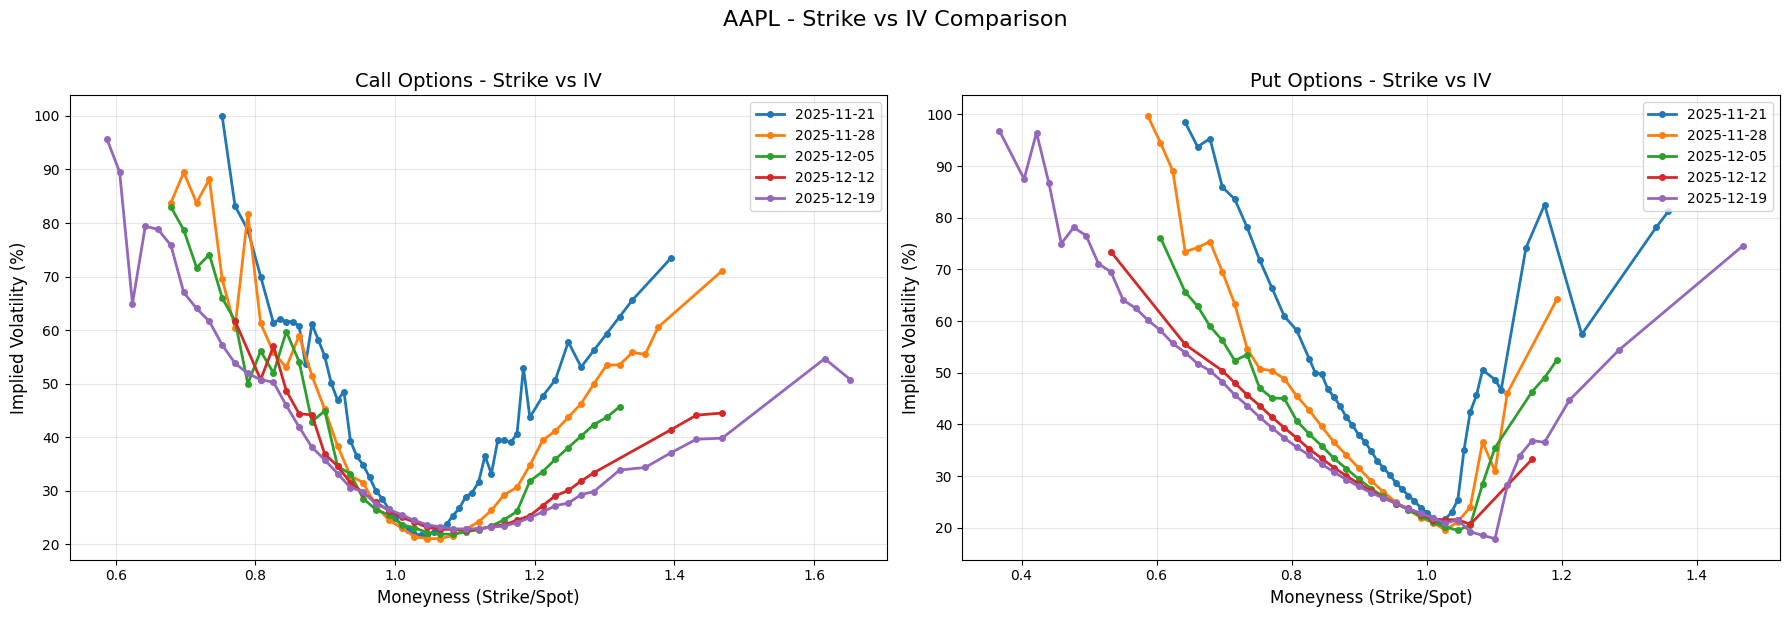

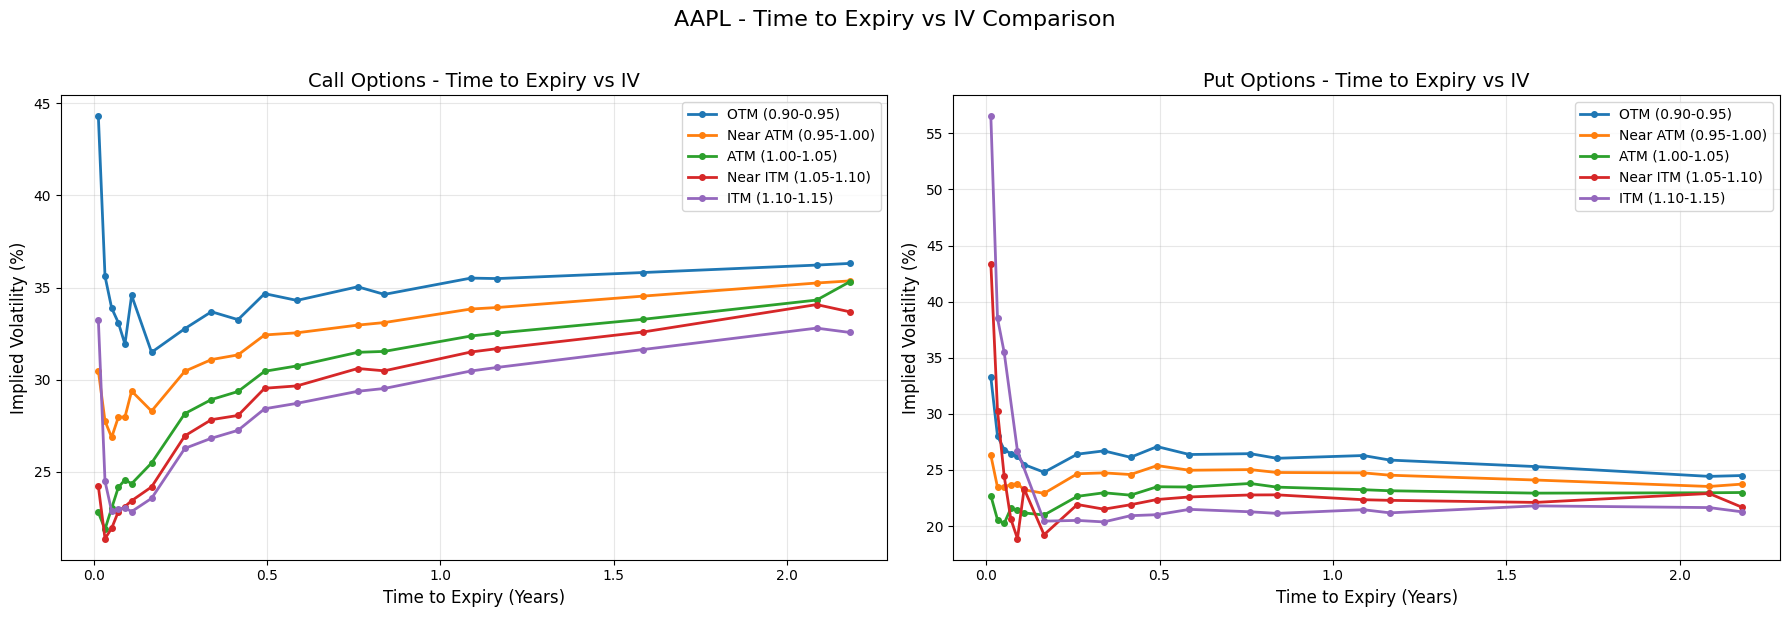

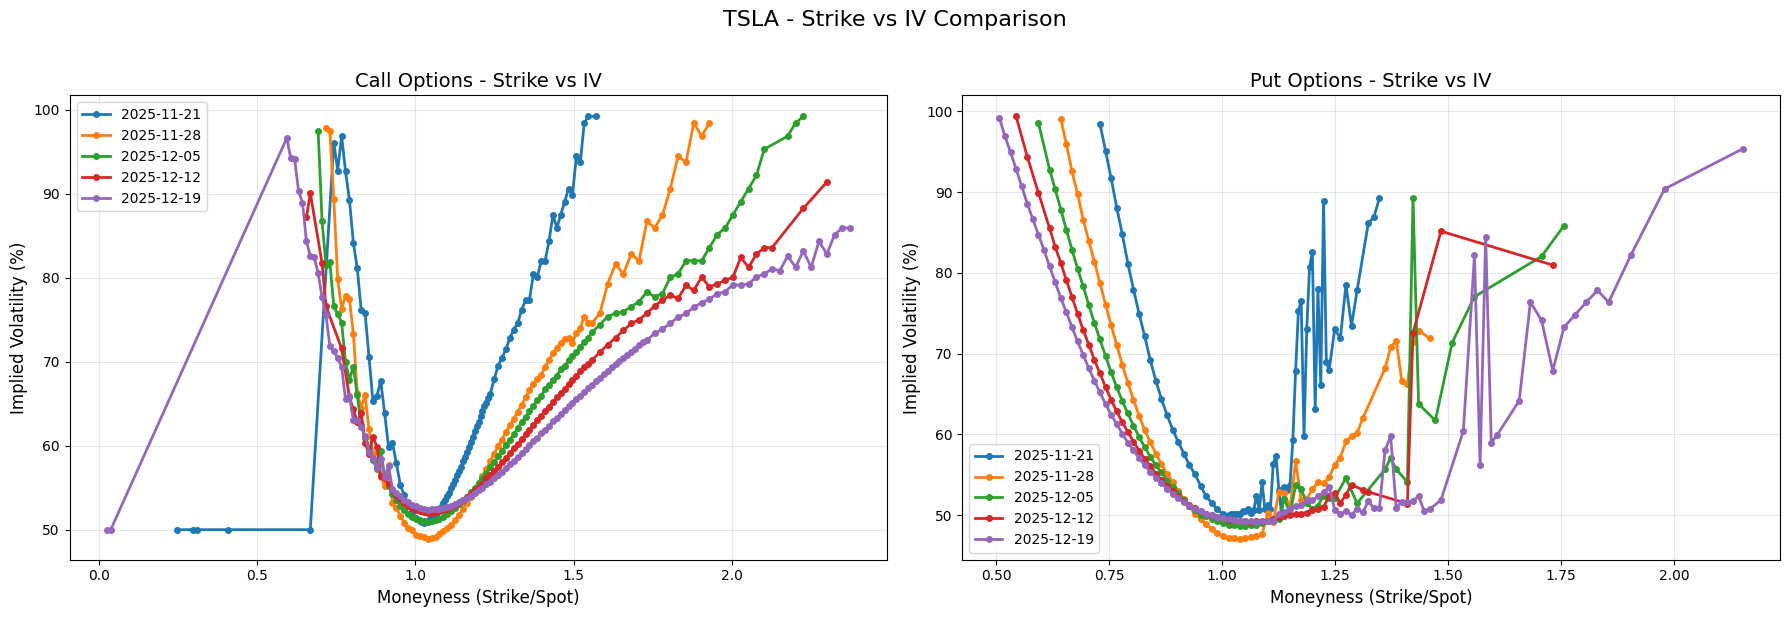

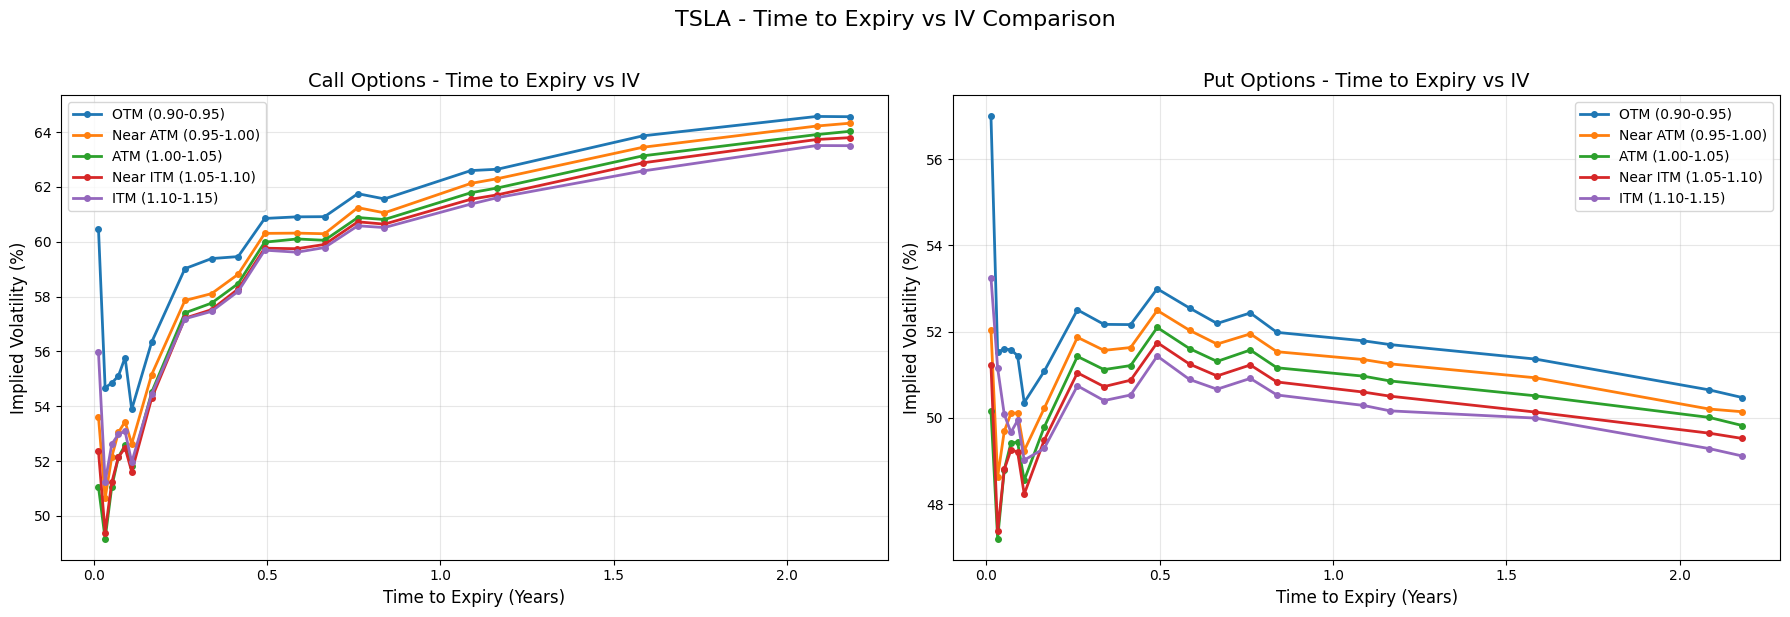

In [2]:
tickers = ["AAPL", "TSLA"]
for ticker in tickers:
    try:
        analyze_ticker(ticker)
    except Exception as e:
        print(f"Error analyzing {ticker}: {str(e)}\n")
        continue

